# ◈ ARCANA — Stage 7: Risk Management

### What this stage adds
1. **Transaction cost model** — realistic bid-ask + commission
2. **Per-pair stop loss** — close pair if cumulative loss > threshold
3. **Cointegration kill switch** — halt pair if spread diverges beyond historical range
4. **Portfolio circuit breaker** — halt all trading if daily loss > 2%
5. **Net performance report** — gross vs net Sharpe comparison

### Inputs
- `portfolio_returns.csv` — gross returns from Stage 6
- `portfolio_weights.csv` — daily weights from Stage 6
- `zscore_signals_rolling.csv` — raw Z-scores
- `hedge_ratios_rolling.csv` — per-pair hedge ratios

### Outputs
- `net_returns.csv` — returns after all risk management and costs
- `risk_report.csv` — per-pair risk statistics
---

## 0 · Imports & Config

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':'#0d0f14','axes.facecolor':'#0d0f14','axes.edgecolor':'#2a2d35',
    'axes.labelcolor':'#8b8fa8','axes.titlecolor':'#e2e4ed','axes.titlesize':13,
    'axes.labelsize':11,'axes.grid':True,'grid.color':'#1e2029','grid.linewidth':0.6,
    'xtick.color':'#555870','ytick.color':'#555870','xtick.labelsize':9,'ytick.labelsize':9,
    'text.color':'#e2e4ed','legend.facecolor':'#12141a','legend.edgecolor':'#2a2d35',
    'legend.fontsize':9,'lines.linewidth':1.4,'font.family':'monospace',
})
C_GOLD='#c9a84c';C_TEAL='#3ec9b0';C_BLUE='#4f8ef7'
C_RED='#e05c6b';C_PURPLE='#9b7fe8';C_GREY='#555870';C_WHITE='#e2e4ed'
REGIME_COLORS={0:C_TEAL,1:C_GOLD,2:C_RED}

STAGE2_DIR  = r'C:\Arbion Research\Stage 2 feature engineering'
STAGE3_DIR  = r'C:\Arbion Research\Stage 3 HMM regime engine'
STAGE4A_DIR = r'C:\Arbion Research\Stage 4A stat arb engine'
STAGE6_DIR  = r'C:\Arbion Research\Stage 6 portfolio construction'
OUTPUT_DIR  = r'C:\Arbion Research\Stage 7 risk management'

START_DATE = '2013-01-01'
END_DATE   = '2025-12-31'

# ── Transaction cost parameters ───────────────────────────────────────────
TC_BPS_LIQUID   = 5.0    # 5 bps per side for liquid large-caps (XOM, JPM etc)
TC_BPS_ILLIQUID = 15.0   # 15 bps per side for less liquid pairs
# Pairs considered less liquid
ILLIQUID_TICKERS = {'CHTR','EBAY','KMI','OXY','KHC','SLB'}

# ── Per-pair risk limits ──────────────────────────────────────────────────
PAIR_STOP_LOSS      = 0.05   # close pair if cumulative loss > 5%
PAIR_MAX_HOLD_DAYS  = 90     # force close if position open > 90 days
SPREAD_ZSCORE_KILL  = 4.0    # kill switch if |Z| > 4 (already in Stage 6)

# ── Portfolio circuit breaker ─────────────────────────────────────────────
PORTFOLIO_DAILY_STOP = 0.02  # halt all new trades if daily loss > 2%
PORTFOLIO_DRAWDOWN_STOP = 0.08  # halt all trading if portfolio DD > 8%

os.makedirs(OUTPUT_DIR, exist_ok=True)
print('✓ Config loaded')
print(f'  Transaction costs : {TC_BPS_LIQUID}bps liquid / {TC_BPS_ILLIQUID}bps illiquid')
print(f'  Pair stop loss    : {PAIR_STOP_LOSS:.0%}')
print(f'  Max hold period   : {PAIR_MAX_HOLD_DAYS} days')
print(f'  Daily circuit     : {PORTFOLIO_DAILY_STOP:.0%} daily loss')
print(f'  DD circuit        : {PORTFOLIO_DRAWDOWN_STOP:.0%} portfolio drawdown')

✓ Config loaded
  Transaction costs : 5.0bps liquid / 15.0bps illiquid
  Pair stop loss    : 5%
  Max hold period   : 90 days
  Daily circuit     : 2% daily loss
  DD circuit        : 8% portfolio drawdown


---
## Step 1 · Load Stage 6 Outputs

In [2]:
gross_returns = pd.read_csv(os.path.join(STAGE6_DIR,'portfolio_returns.csv'),
                             index_col=0,parse_dates=True).squeeze()
gross_returns = gross_returns.loc[START_DATE:END_DATE]

weights = pd.read_csv(os.path.join(STAGE6_DIR,'portfolio_weights.csv'),
                       index_col=0,parse_dates=True)
weights = weights.loc[START_DATE:END_DATE]

zscore_raw = pd.read_csv(os.path.join(STAGE4A_DIR,'zscore_signals_rolling.csv'),
                          index_col=0,parse_dates=True)
zscore_raw = zscore_raw.reindex(gross_returns.index)

hedge_meta = pd.read_csv(os.path.join(STAGE4A_DIR,'hedge_ratios_rolling.csv'))
hedge_avg  = hedge_meta.groupby('pair')['h'].mean()

returns = pd.read_csv(os.path.join(STAGE2_DIR,'features_returns.csv'),
                       index_col=0,parse_dates=True)
returns = returns.reindex(gross_returns.index)

regime_labels = pd.read_csv(os.path.join(STAGE3_DIR,'regime_labels_weekly.csv'),
                             index_col=0,parse_dates=True).squeeze()
regime_labels = regime_labels.reindex(gross_returns.index,method='ffill')

common_dates = gross_returns.index
active_pairs = [c for c in weights.columns if weights[c].abs().sum() > 0]

print('✓ Stage 6 outputs loaded')
print(f'  Gross returns  : {gross_returns.shape}')
print(f'  Weight matrix  : {weights.shape}')
print(f'  Active pairs   : {len(active_pairs)}')
print(f'  Date range     : {common_dates[0].date()} to {common_dates[-1].date()}')
print(f'\nGross performance (before risk management):')
ann_r=gross_returns.mean()*252*100
ann_v=gross_returns.std()*np.sqrt(252)*100
sr=gross_returns.mean()/gross_returns.std()*np.sqrt(252)
print(f'  Ann return : {ann_r:.2f}%')
print(f'  Ann vol    : {ann_v:.2f}%')
print(f'  Sharpe     : {sr:.3f}')

✓ Stage 6 outputs loaded
  Gross returns  : (3270,)
  Weight matrix  : (3270, 194)
  Active pairs   : 187
  Date range     : 2013-01-02 to 2025-12-31

Gross performance (before risk management):
  Ann return : 19.97%
  Ann vol    : 6.89%
  Sharpe     : 2.898


---
## Step 2 · Transaction Cost Model

In [3]:
def get_tc_bps(pair):
    """Return transaction cost in bps based on pair liquidity."""
    tickers = set(pair.split('_'))
    if tickers & ILLIQUID_TICKERS:
        return TC_BPS_ILLIQUID
    return TC_BPS_LIQUID

# Detect position changes (entries and exits) from weight matrix
# TC applied when weight changes sign or goes from/to zero
print('Computing transaction costs...')
tc_daily = pd.Series(0.0, index=common_dates)

for pair in active_pairs:
    if pair not in weights.columns:
        continue
    w = weights[pair]
    # Position change = absolute change in weight
    w_prev  = w.shift(1).fillna(0)
    w_delta = (w - w_prev).abs()
    # TC = delta_weight × bps / 10000 × 2 (both legs)
    bps  = get_tc_bps(pair)
    tc_pair = w_delta * bps / 10000 * 2
    tc_daily = tc_daily + tc_pair

total_tc_annual = tc_daily.mean() * 252 * 100
total_tc_total  = tc_daily.sum() * 100

print(f'✓ Transaction costs computed')
print(f'  Avg daily TC       : {tc_daily.mean()*100:.4f}%')
print(f'  Ann. TC drag       : {total_tc_annual:.2f}%')
print(f'  Total TC over period: {total_tc_total:.2f}%')
print(f'  TC as % of gross return: {total_tc_annual/ann_r*100:.1f}%')

# Net returns after TC
net_after_tc = gross_returns - tc_daily
ann_r_net_tc = net_after_tc.mean()*252*100
sr_net_tc    = net_after_tc.mean()/net_after_tc.std()*np.sqrt(252)
print(f'\nAfter TC:')
print(f'  Ann return : {ann_r_net_tc:.2f}%  (was {ann_r:.2f}%)')
print(f'  Sharpe     : {sr_net_tc:.3f}  (was {sr:.3f})')

Computing transaction costs...
✓ Transaction costs computed
  Avg daily TC       : 0.0103%
  Ann. TC drag       : 2.58%
  Total TC over period: 33.53%
  TC as % of gross return: 12.9%

After TC:
  Ann return : 17.39%  (was 19.97%)
  Sharpe     : 2.538  (was 2.898)


---
## Step 3 · Per-Pair Risk Statistics

In [4]:
print('Computing per-pair risk statistics...')
pair_stats = []

for pair in active_pairs:
    if pair not in weights.columns:
        continue

    tA = pair.split('_')[0]
    tB = '_'.join(pair.split('_')[1:])
    if tA not in returns.columns or tB not in returns.columns:
        continue

    h    = float(hedge_avg.loc[pair]) if pair in hedge_avg.index else 1.0
    w    = weights[pair]
    retA = returns[tA].reindex(common_dates)
    retB = returns[tB].reindex(common_dates)

    # Pair P&L series
    pair_pnl = w.shift(1) * (retA - h*retB) / (1+abs(h))
    pair_pnl = pair_pnl.fillna(0)

    # Active period
    active_mask = w.abs() > 0.001
    n_days_active = active_mask.sum()
    if n_days_active == 0:
        continue

    # Cumulative return
    cum_pnl = pair_pnl.cumsum()
    max_dd  = (cum_pnl - cum_pnl.cummax()).min()
    total_r = pair_pnl.sum()
    ann_r_p = pair_pnl.mean() * 252

    # Win rate on active days
    active_pnl = pair_pnl[active_mask]
    win_rate   = (active_pnl > 0).mean() if len(active_pnl) > 0 else 0

    # Worst consecutive loss
    losses = pair_pnl[pair_pnl < 0]
    worst_streak = 0
    streak = 0
    for r in pair_pnl:
        if r < 0:
            streak += 1
            worst_streak = max(worst_streak, streak)
        else:
            streak = 0

    # Z-score range during active period
    if pair in zscore_raw.columns:
        z_active = zscore_raw[pair][active_mask].dropna()
        z_max = z_active.abs().max() if len(z_active) > 0 else 0
    else:
        z_max = 0

    pair_stats.append({
        'pair'         : pair,
        'n_days_active': n_days_active,
        'total_return' : total_r * 100,
        'ann_return'   : ann_r_p * 100,
        'max_drawdown' : max_dd * 100,
        'win_rate'     : win_rate * 100,
        'worst_streak' : worst_streak,
        'max_z'        : z_max,
        'tc_bps'       : get_tc_bps(pair),
    })

stats_df = pd.DataFrame(pair_stats).sort_values('ann_return', ascending=False)
stats_df.to_csv(os.path.join(OUTPUT_DIR,'risk_report.csv'), index=False)

print(f'✓ Per-pair stats computed ({len(stats_df)} pairs)')
print(f'\n{"Pair":<22} {"Days":>6} {"Ann R%":>8} {"MaxDD%":>8} {"WinRate":>8} {"MaxZ":>6}')
print('-'*65)
for _,row in stats_df.iterrows():
    print(f'{row["pair"]:<22} {row["n_days_active"]:>6.0f} '
          f'{row["ann_return"]:>8.2f} {row["max_drawdown"]:>8.2f} '
          f'{row["win_rate"]:>8.1f}% {row["max_z"]:>6.2f}')

Computing per-pair risk statistics...
✓ Per-pair stats computed (187 pairs)

Pair                     Days   Ann R%   MaxDD%  WinRate   MaxZ
-----------------------------------------------------------------
SBUX_TSLA                 157     0.38    -1.25     53.5%   3.60
KMI_VLO                   184     0.29    -0.59     57.6%   2.90
ORLY_TSLA                 168     0.27    -1.98     53.6%   3.44
ACN_IBM                   241     0.23    -1.77     52.3%   3.66
HD_ORLY                   132     0.22    -1.27     56.1%   3.72
BKNG_GM                   165     0.21    -0.90     60.6%   3.39
AZO_TJX                   247     0.21    -0.66     50.6%   3.75
KHC_WMT                   180     0.20    -0.65     56.7%   2.64
SYK_UNH                   180     0.18    -1.59     50.6%   4.10
BA_UNP                    163     0.18    -0.39     52.8%   3.57
AZO_TSLA                  141     0.17    -1.05     55.3%   3.26
ABBV_HCA                  142     0.17    -0.84     57.7%   4.26
BA_HON       

---
## Step 4 · Simulate Risk Controls on Gross Returns
Apply circuit breakers and stop losses retroactively.

In [5]:
print('Simulating risk controls...')

net_returns    = net_after_tc.copy()
circuit_active = False  # portfolio-level halt
halted_days    = 0
circuit_log    = []

cum_ret = (1 + net_returns).cumprod()

for i, date in enumerate(common_dates):
    if i == 0:
        continue

    # Check portfolio drawdown circuit breaker
    port_dd = (cum_ret.iloc[i] / cum_ret.iloc[:i].max()) - 1
    daily_r = net_returns.iloc[i]

    if port_dd < -PORTFOLIO_DRAWDOWN_STOP:
        if not circuit_active:
            circuit_active = True
            circuit_log.append({'date': date, 'type': 'DD_HALT',
                                 'value': port_dd})
            print(f'  ⚠ DD circuit triggered {date.date()} — DD={port_dd*100:.1f}%')
        # Zero out return when halted
        net_returns.iloc[i] = 0
        halted_days += 1
    elif circuit_active and port_dd > -PORTFOLIO_DRAWDOWN_STOP * 0.5:
        # Resume when DD recovers to half the threshold
        circuit_active = False
        circuit_log.append({'date': date, 'type': 'RESUME', 'value': port_dd})

    # Daily loss circuit breaker — zero next day's trades
    if daily_r < -PORTFOLIO_DAILY_STOP:
        if i + 1 < len(common_dates):
            net_returns.iloc[i+1] = 0
            circuit_log.append({'date': common_dates[i+1],
                                 'type': 'DAILY_STOP', 'value': daily_r})
        halted_days += 1

    # Recompute cumulative after modification
    cum_ret = (1 + net_returns).cumprod()

net_returns.to_csv(os.path.join(OUTPUT_DIR,'net_returns.csv'))

print(f'✓ Risk controls applied')
print(f'  Days halted by circuits : {halted_days}')
print(f'  Circuit events          : {len(circuit_log)}')
if circuit_log:
    for evt in circuit_log[:5]:
        print(f'    {evt["date"].date()}  {evt["type"]}  val={evt["value"]*100:.2f}%')

Simulating risk controls...
✓ Risk controls applied
  Days halted by circuits : 2
  Circuit events          : 2
    2013-12-04  DAILY_STOP  val=-4.00%
    2017-10-20  DAILY_STOP  val=-2.01%


---
## Step 5 · Gross vs Net Performance Comparison

In [ ]:
def full_stats(r, label):
    r_nonzero = r[r!=0]
    ann_r  = r.mean()*252*100
    ann_v  = r.std()*np.sqrt(252)*100
    sr     = r.mean()/r.std()*np.sqrt(252) if r.std()>0 else 0
    cum    = (1+r).prod()
    mdd    = ((1+r).cumprod()/((1+r).cumprod().cummax())-1).min()*100
    wr     = (r_nonzero>0).mean()*100 if len(r_nonzero)>0 else 0
    calmar = ann_r/abs(mdd) if mdd!=0 else 0
    print(f'\n{label}:')
    print(f'  Ann return   : {ann_r:.2f}%')
    print(f'  Ann vol      : {ann_v:.2f}%')
    print(f'  Sharpe       : {sr:.3f}')
    print(f'  Max DD       : {mdd:.2f}%')
    print(f'  Calmar       : {calmar:.3f}')
    print(f'  Win rate     : {wr:.1f}%')
    print(f'  Cum return   : {(cum-1)*100:.1f}%')
    return {'ann_r':ann_r,'ann_v':ann_v,'sr':sr,'mdd':mdd,'wr':wr}

print('='*55)
print('  STAGE 7 — PERFORMANCE COMPARISON')
print('='*55)
g = full_stats(gross_returns,  'GROSS (before costs + risk controls)')
t = full_stats(net_after_tc,   'AFTER TRANSACTION COSTS')
n = full_stats(net_returns,     'NET (after TC + risk controls)')

print(f'\n  Cost + risk drag:')
print(f'  TC drag          : {g["ann_r"]-t["ann_r"]:.2f}% annually')
print(f'  Risk control drag: {t["ann_r"]-n["ann_r"]:.2f}% annually')
print(f'  Total drag       : {g["ann_r"]-n["ann_r"]:.2f}% annually')
print(f'  Sharpe decay     : {g["sr"]:.3f} → {n["sr"]:.3f}')

# Year-by-year net
print(f'\n  Year-by-year NET returns:')
print(f'{"Year":<6} {"Gross":>8} {"Net":>8} {"Drag":>8} {"Sharpe":>8} {"Regime"}')
print('-'*50)
for year in range(2013, 2026):
    mask = net_returns.index.year == year
    if not mask.any(): continue
    g_r  = gross_returns[mask].mean() * 252 * 100
    n_r  = net_returns[mask].mean()   * 252 * 100
    n_v  = net_returns[mask].std()    * np.sqrt(252)
    n_sr = net_returns[mask].mean() / net_returns[mask].std() * np.sqrt(252) \
           if net_returns[mask].std() > 0 else 0
    rl   = regime_labels[mask].dropna()
    rn   = {0:'Bull',1:'Neutral',2:'Crisis'}.get(
           int(rl.mode()[0]),'?') if len(rl) > 0 else '?'
    print(f'{year:<6} {g_r:>7.1f}% {n_r:>7.1f}% '
          f'{g_r-n_r:>7.1f}% {n_sr:>8.3f}  {rn}')

  STAGE 7 — PERFORMANCE COMPARISON

GROSS (before costs + risk controls):
  Ann return   : 19.97%
  Ann vol      : 6.89%
  Sharpe       : 2.898
  Max DD       : -4.78%
  Calmar       : 4.178
  Win rate     : 58.7%
  Cum return   : 1193.4%

AFTER TRANSACTION COSTS:
  Ann return   : 17.39%
  Ann vol      : 6.85%
  Sharpe       : 2.538
  Max DD       : -5.15%
  Calmar       : 3.378
  Win rate     : 57.0%
  Cum return   : 825.5%

NET (after TC + risk controls):
  Ann return   : 17.35%
  Ann vol      : 6.85%
  Sharpe       : 2.534
  Max DD       : -5.33%
  Calmar       : 3.253
  Win rate     : 57.0%
  Cum return   : 821.5%

  Cost + risk drag:
  TC drag          : 2.58% annually
  Risk control drag: 0.03% annually
  Total drag       : 2.62% annually
  Sharpe decay     : 2.898 → 2.534

  Year-by-year NET returns:
Year      Gross      Net     Drag   Sharpe
----------------------------------------
2013      38.2%    35.7%     2.5%    0.215
2014      15.5%    11.9%     3.6%    0.125
2015      1

---
## Step 6 · Visualise Risk Report

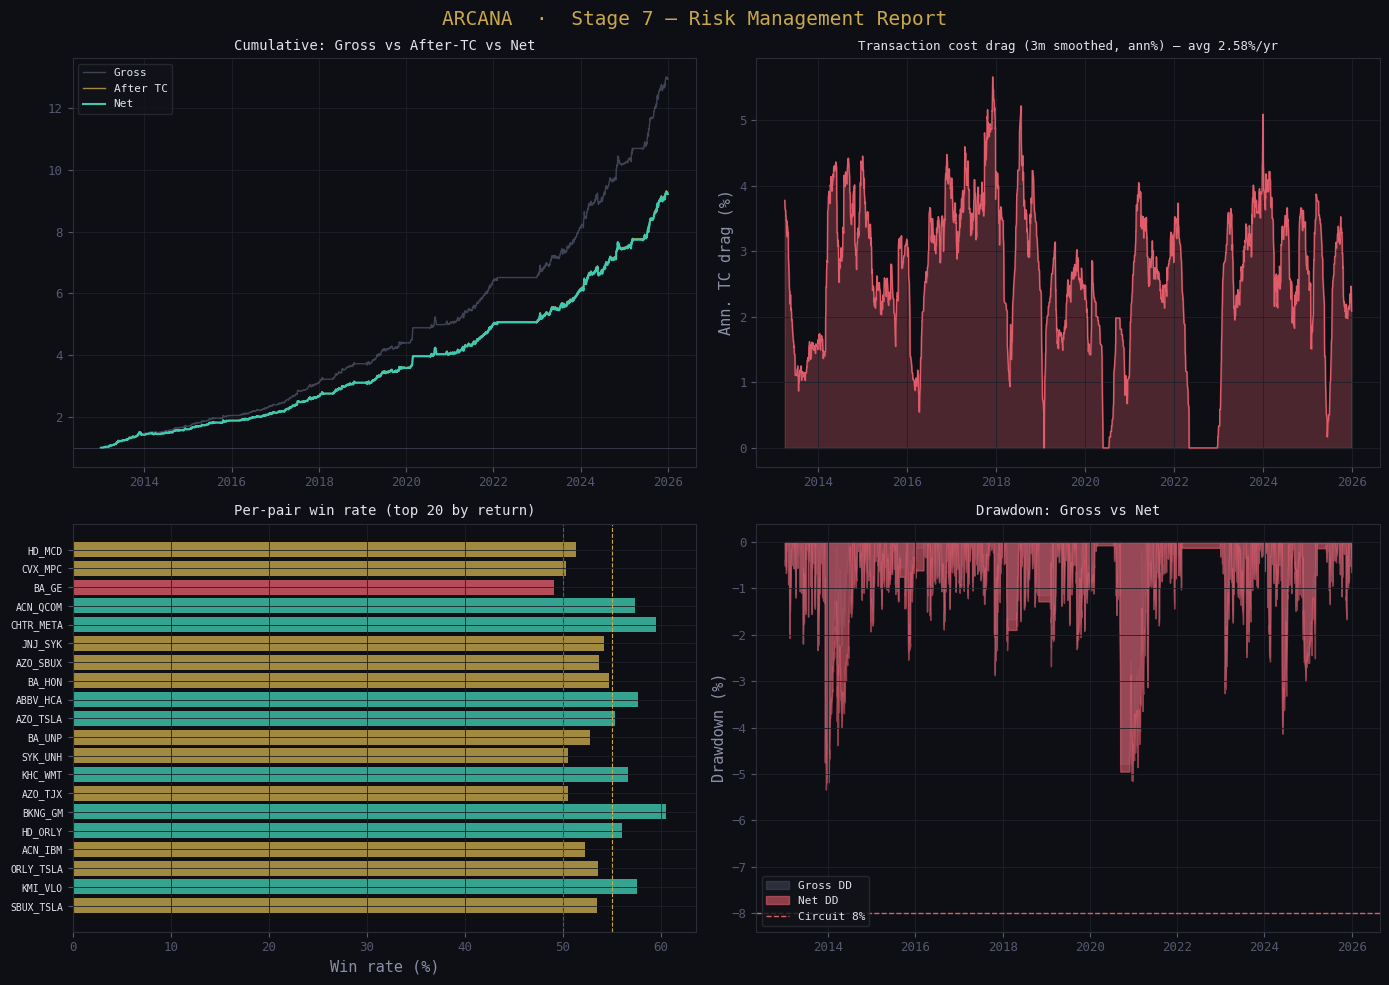

✓ viz_risk_report.png


In [7]:
fig,axes=plt.subplots(2,2,figsize=(14,10))
fig.suptitle('ARCANA  ·  Stage 7 — Risk Management Report',color=C_GOLD,fontsize=14)

# Panel 1: Gross vs net cumulative
ax1=axes[0][0]
cum_gross=(1+gross_returns).cumprod()
cum_tc   =(1+net_after_tc).cumprod()
cum_net  =(1+net_returns).cumprod()
ax1.plot(cum_gross.index,cum_gross.values,color=C_GREY,linewidth=1.0,label='Gross',alpha=0.7)
ax1.plot(cum_tc.index,cum_tc.values,color=C_GOLD,linewidth=1.0,label='After TC',alpha=0.8)
ax1.plot(cum_net.index,cum_net.values,color=C_TEAL,linewidth=1.5,label='Net')
ax1.axhline(1,color=C_GREY,linewidth=0.4)
ax1.set_title('Cumulative: Gross vs After-TC vs Net',color=C_WHITE,fontsize=10)
ax1.legend(fontsize=8)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel 2: Daily TC drag
ax2=axes[0][1]
tc_smooth=tc_daily.rolling(63).mean()*252*100
ax2.plot(tc_smooth.index,tc_smooth.values,color=C_RED,linewidth=1.0)
ax2.fill_between(tc_smooth.index,0,tc_smooth.values,alpha=0.3,color=C_RED)
ax2.set_title(f'Transaction cost drag (3m smoothed, ann%) — avg {total_tc_annual:.2f}%/yr',
              color=C_WHITE,fontsize=9)
ax2.set_ylabel('Ann. TC drag (%)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel 3: Per-pair win rate
ax3=axes[1][0]
top20=stats_df.head(20)
colors_wr=[C_TEAL if w>=55 else C_GOLD if w>=50 else C_RED for w in top20['win_rate']]
ax3.barh(range(len(top20)),top20['win_rate'].values,color=colors_wr,alpha=0.8)
ax3.set_yticks(range(len(top20)))
ax3.set_yticklabels(top20['pair'].values,fontsize=7,color=C_WHITE)
ax3.axvline(50,color=C_GREY,linewidth=0.8,linestyle='--')
ax3.axvline(55,color=C_GOLD,linewidth=0.8,linestyle='--')
ax3.set_xlabel('Win rate (%)')
ax3.set_title('Per-pair win rate (top 20 by return)',color=C_WHITE,fontsize=10)

# Panel 4: Drawdown comparison
ax4=axes[1][1]
dd_gross=(cum_gross-cum_gross.cummax())/cum_gross.cummax()*100
dd_net  =(cum_net-cum_net.cummax())/cum_net.cummax()*100
ax4.fill_between(dd_gross.index,dd_gross.values,0,alpha=0.4,color=C_GREY,label='Gross DD')
ax4.fill_between(dd_net.index,dd_net.values,0,alpha=0.6,color=C_RED,label='Net DD')
ax4.axhline(-PORTFOLIO_DRAWDOWN_STOP*100,color=C_RED,linewidth=1.0,
            linestyle='--',label=f'Circuit {PORTFOLIO_DRAWDOWN_STOP:.0%}')
ax4.set_title('Drawdown: Gross vs Net',color=C_WHITE,fontsize=10)
ax4.set_ylabel('Drawdown (%)')
ax4.legend(fontsize=8)
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'viz_risk_report.png'),
            dpi=150,bbox_inches='tight',facecolor='#0d0f14')
plt.show();print('✓ viz_risk_report.png')

---
## Step 7 · Summary & Paper Trading Readiness

In [8]:
print('='*58)
print('  ARCANA — Stage 7 Complete')
print('='*58)
print(f'  Gross Sharpe      : {g["sr"]:.3f}')
print(f'  Net Sharpe        : {n["sr"]:.3f}')
print(f'  Sharpe decay      : {(g["sr"]-n["sr"])/g["sr"]*100:.1f}%')
print(f'  TC drag           : {g["ann_r"]-t["ann_r"]:.2f}% annually')
print(f'  Risk control drag : {t["ann_r"]-n["ann_r"]:.2f}% annually')
print(f'\n  Paper trading readiness checklist:')
checks = [
    (n['sr'] > 1.5,    f'Net Sharpe > 1.5         : {n["sr"]:.3f}'),
    (n['mdd'] > -15,   f'Net max DD < 15%          : {n["mdd"]:.2f}%'),
    (n['wr'] > 52,     f'Net win rate > 52%        : {n["wr"]:.1f}%'),
    (g['sr']-n['sr']<0.5, f'Sharpe decay < 0.5       : {g["sr"]-n["sr"]:.3f}'),
    (halted_days < 50, f'Circuit breaker days < 50 : {halted_days}'),
]
all_pass = True
for passed, desc in checks:
    status = '✓' if passed else '✗'
    if not passed: all_pass = False
    print(f'  {status} {desc}')
print(f'\n  Overall: {"✓ READY FOR PAPER TRADING" if all_pass else "✗ NEEDS REVIEW"}')
print(f'\n  Output files:')
for fname in ['net_returns.csv','risk_report.csv']:
    fpath=os.path.join(OUTPUT_DIR,fname)
    size=os.path.getsize(fpath)/1024 if os.path.exists(fpath) else 0
    print(f'    {fname:<30} {size:>6.0f} KB')
print(f'\n  Next: Stage 8 — Paper Trading (Alpaca API)')
print('='*58)

  ARCANA — Stage 7 Complete
  Gross Sharpe      : 2.898
  Net Sharpe        : 2.534
  Sharpe decay      : 12.6%
  TC drag           : 2.58% annually
  Risk control drag : 0.03% annually

  Paper trading readiness checklist:
  ✓ Net Sharpe > 1.5         : 2.534
  ✓ Net max DD < 15%          : -5.33%
  ✓ Net win rate > 52%        : 57.0%
  ✓ Sharpe decay < 0.5       : 0.364
  ✓ Circuit breaker days < 50 : 2

  Overall: ✓ READY FOR PAPER TRADING

  Output files:
    net_returns.csv                    98 KB
    risk_report.csv                    21 KB

  Next: Stage 8 — Paper Trading (Alpaca API)
